## Missing Values
Missing values occurs in dataset when some of the informations is not stored for a variable
There are 3 mechanisms

### 1 Missing Completely at Random, MCAR:
Missing completely at random (MCAR) is a type of missing data mechanism in which the probability of a value being missing is unrelated to both the observed data and the missing data. In other words, if the data is MCAR, the missing values are randomly distributed throughout the dataset, and there is no systematic reason for why they are missing.

For example, in a survey about the prevalence of a certain disease, the missing data might be MCAR if the survey participants with missing values for certain questions were selected randomly and their missing responses are not related to their disease status or any other variables measured in the survey.


### 2. Missing at Random MAR:
Missing at Random (MAR) is a type of missing data mechanism in which the probability of a value being missing depends only on the observed data, but not on the missing data itself. In other words, if the data is MAR, the missing values are systematically related to the observed data, but not to the missing data.
Here are a few examples of missing at random:

Income data: Suppose you are collecting income data from a group of people, but some participants choose not to report their income. If the decision to report or not report income is related to the participant's age or gender, but not to their income level, then the data is missing at random.

Medical data: Suppose you are collecting medical data on patients, including their blood pressure, but some patients do not report their blood pressure. If the patients who do not report their blood pressure are more likely to be younger or have healthier lifestyles, but the missingness is not related to their actual blood pressure values, then the data is missing at random.

## 3. Missing data not at random (MNAR) 
It is a type of missing data mechanism where the probability of missing values depends on the value of the missing data itself. In other words, if the data is MNAR, the missingness is not random and is dependent on unobserved or unmeasured factors that are associated with the missing values.

For example, suppose you are collecting data on the income and job satisfaction of employees in a company. If employees who are less satisfied with their jobs are more likely to refuse to report their income, then the data is not missing at random. In this case, the missingness is dependent on job satisfaction, which is not directly observed or measured.

## Examples

## Step 1 — Build the dataset

In [2]:
!pip install pandas matplotlib

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

In [31]:
np.random.seed(42)
number_of_samples = 10000
number_of_good = int(number_of_samples * 0.9)
number_of_default = number_of_samples - number_of_good

In [39]:
regions = ['Colombo', 'Kandy', 'Galle', 'Jaffna', 'Kurunegala', 'Trincomalee']
employee_types = ['Salaried', 'Self-employed', 'Interns']

good_samples = pd.DataFrame({
    'customer_id' : [f'C{i:04d}' for i in range(number_of_good)],
    'age': np.int32(np.random.normal(38, 9, number_of_good).clip(21, 55).round(0)),
    'monthly_income': np.random.normal(85000, 25000, number_of_good).clip(20000, None).round(0),
    'employment_type': np.random.choice(employee_types, number_of_good, p=[0.5, 0.3, 0.2]),
    'credit_score': np.random.normal(700, 60, number_of_good).clip(300, 850).round(0),
    'region': np.random.choice(regions, number_of_good, p=[0.4, 0.2, 0.15, 0.1, 0.1, 0.05]),
    'defaulted': 0
})

good_samples.head()

,customer_id,age,monthly_income,employment_type,credit_score,region,defaulted
0,C0000,41,123502.0,Interns,741.0,Galle,0
1,C0001,31,113145.0,Salaried,715.0,Colombo,0
2,C0002,37,76990.0,Salaried,666.0,Colombo,0
3,C0003,29,107354.0,Self-employed,840.0,Kandy,0
4,C0004,32,121518.0,Self-employed,706.0,Colombo,0


In [40]:
bad_samples = pd.DataFrame({
    'customer_id' : [f'C{i:04d}' for i in range(number_of_default)],
    'age': np.int32(np.random.normal(42, 10, number_of_default).clip(21, 55).round(0)),
    'monthly_income': np.random.normal(55000, 20000, number_of_default).clip(15000, None).round(0),
    'employment_type': np.random.choice(employee_types, number_of_default, p=[0.5, 0.3, 0.2]),
    'credit_score': np.random.normal(580, 55, number_of_default).clip(300, 850).round(0),
    'region': np.random.choice(regions, number_of_default, p=[0.4, 0.2, 0.15, 0.1, 0.1, 0.05]),
    'defaulted': 1
})
bad_samples

,customer_id,age,monthly_income,employment_type,credit_score,region,defaulted
0,C0000,53,80253.0,Interns,588.0,Colombo,1
1,C0001,47,38862.0,Salaried,542.0,Galle,1
2,C0002,50,30275.0,Salaried,528.0,Galle,1
3,C0003,48,36472.0,Salaried,538.0,Colombo,1
4,C0004,41,62205.0,Self-employed,607.0,Kurunegala,1
...,...,...,...,...,...,...,...
995,C0995,30,45421.0,Interns,544.0,Colombo,1
996,C0996,55,63846.0,Interns,617.0,Kandy,1
997,C0997,27,20488.0,Salaried,689.0,Colombo,1
998,C0998,28,19304.0,Salaried,549.0,Colombo,1


In [41]:
df = pd.concat([good_samples, bad_samples]).reset_index(drop=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df

,customer_id,age,monthly_income,employment_type,credit_score,region,defaulted
0,C6252,45,121019.0,Salaried,693.0,Jaffna,0
1,C4684,24,89381.0,Salaried,621.0,Kandy,0
2,C1731,26,20000.0,Salaried,786.0,Colombo,0
3,C4742,55,62638.0,Interns,570.0,Galle,0
4,C4521,33,96666.0,Salaried,791.0,Kandy,0
...,...,...,...,...,...,...,...
9995,C5734,43,73108.0,Salaried,695.0,Kandy,0
9996,C5191,47,67478.0,Salaried,704.0,Kandy,0
9997,C5390,35,64875.0,Interns,627.0,Colombo,0
9998,C0860,35,90189.0,Interns,756.0,Kandy,0


## Step 2 — Inject 3 different kinds of missingness (for demonstration)

- `credit_score` → **MCAR**: a bureau lookup randomly fails, unrelated to anything else.
- `region` → **MAR**: self-employed customers are less likely to have region recorded — depends on the *observed* `employment_type` column.
- `monthly_income` → **MNAR**: customers about to default are more likely to skip reporting income — depends on the *hidden* target itself.

In [42]:
rng = np.random.default_rng(42)

# MCAR: credit_score missing completely at random
mcar_idx = rng.choice(df.index, size=int(0.009*number_of_samples), replace=False)
df.loc[mcar_idx, 'credit_score'] = np.nan

In [43]:
# MAR: region missing more often for self-employed customers
self_employed_idx = df[df.employment_type == 'Self-employed'].index
mar_idx = rng.choice(self_employed_idx, size=int(0.25*len(self_employed_idx)), replace=False)
df.loc[mar_idx, 'region'] = np.nan

In [44]:
# MNAR: income missing more often for defaulters
bad_idx = df[df.defaulted == 1].index
good_idx = df[df.defaulted == 0].index

mnar_bad = rng.choice(bad_idx, size=int(0.10*len(bad_idx)), replace=False)
mnar_good = rng.choice(good_idx, size=int(0.04*len(good_idx)), replace=False)
df.loc[np.concatenate([mnar_bad, mnar_good]), 'monthly_income'] = np.nan

df.isnull().sum()

customer_id          0
age                  0
monthly_income     460
employment_type      0
credit_score        90
region             742
defaulted            0
dtype: int64

## Step 3 — Quantify before fixing anything

In [45]:
missing_percentage = (df.isnull().sum() / len(df) * 100).round(2)
missing_percentage

customer_id        0.00
age                0.00
monthly_income     4.60
employment_type    0.00
credit_score       0.90
region             7.42
defaulted          0.00
dtype: float64

## Step 4 — Test for an MNAR signal

The key diagnostic question: does missingness in a column correlate with the
target itself? If yes, that's MNAR, and you should NOT just impute blindly —
you're about to erase real signal.

defaulted
0     4.0
1    10.0
Name: monthly_income, dtype: float64


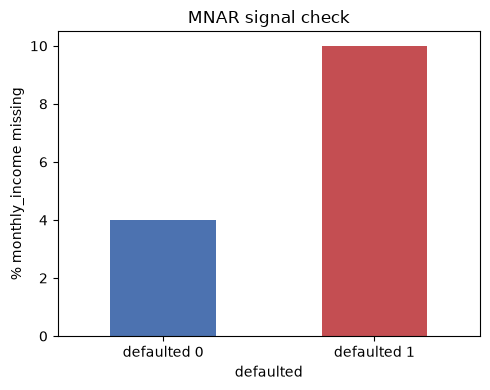

In [46]:
mnar_check = df.groupby('defaulted')['monthly_income'].apply(lambda x : x.isnull().mean()*100)
print(mnar_check.round(2))

fig, ax = plt.subplots(figsize=(5,4))
mnar_check.plot(kind='bar', ax=ax, color=['#4C72B0','#C44E52'])
ax.set_ylabel('% monthly_income missing')
ax.set_title('MNAR signal check')
ax.set_xticklabels(['defaulted 0','defaulted 1'], rotation=0)
plt.tight_layout()
plt.show()

**Reading the result:** defaulters are missing income at roughly **2.5x**
the rate of non-defaulters — this is a real pattern, not noise. That's why we
preserve it as a flag column before imputing, instead of quietly erasing it.

## Step 5 — Apply the right fix per column

| Column | Mechanism | Fix |
|---|---|---|
| `credit_score` | MCAR, numeric, <1% missing | median (robust to outliers) |
| `region` | MAR, categorical | mode **within employment_type group** |
| `monthly_income` | MNAR, numeric | flag column, **then** median-fill |

In [47]:
df['credit_score'] = df['credit_score'].fillna(df['credit_score'].median())
df['region'] = df.groupby('employment_type')['region'].transform(lambda x: x.fillna(x.mode()[0]))
df['income_was_missing'] = df['monthly_income'].isnull().astype(int)
df['monthly_income'] = df['monthly_income'].fillna(df['monthly_income'].median())
df.isnull().sum()

customer_id           0
age                   0
monthly_income        0
employment_type       0
credit_score          0
region                0
defaulted             0
income_was_missing    0
dtype: int64

All columns are now complete, and the MNAR signal in `monthly_income` is
preserved in `income_was_missing` for the model to use downstream.

**Key takeaway:** always diagnose *why* data is missing before choosing a fix —
the mechanism (MCAR/MAR/MNAR) determines whether a simple median/mode fill is
safe, or whether you need to preserve the missingness pattern itself.